# Effective Propositionalisation

Forming an effective propositionalisation of a real-valued dataset is a complex task.

Basic desidarata:

1. consistent, i.e., discretized variable converges to undiscretized variable for $n \to \infty$
2. efficient, i.e., rate of convergence as fast as possible
3. parsimonious, i.e., number of bins / thresholds as small as possible

Additional semantic desiderata:

4. interpretability, bins / thresholds can be named easily
5. mass faithful, values with discrete probability mass obtain dedicated threshold for small $n$, in particular, variables that are already discrete are faithfully reconstructed for small $n$
6. mode faithful, for multi-modal distributions, the discretized variable is able to separate all modes for small $n$

In addition, simplicty is always desired. Hence, we are willing to sacrifice indivudal critera to have, in first instance, a robust and transparent way to approximately satisfy the other criteria via readily available numpy functions. In particular, the investigated candidates are

- quantile-based (equal frequency) discretisation as provided by `numpy.quantiles` with a logarithmic number of thresholds,
- equal width binning methods for density approximation implemented in `numpy.histogram_bin_edges`.

Immediate concern about those approaches that come to mind are:

- Quantile-based discretisation provides uniform binnings, hence, it does not generally allow to separate outliers. This might in the end be related to the mode faithfulness, but there might be other more subtle issues that are unclear without a deeper study of the literature. The histogram methods have a more authorotative feel to them overall when it comes to continuous, mainly by their reference to the literature.

- Equal-width binning, on the other hand, is less transparent and interpretable. In particular, it is not easy to name the resulting thresholds other than through the thresholds themselves (in contrast to percentile-based thresholds). 

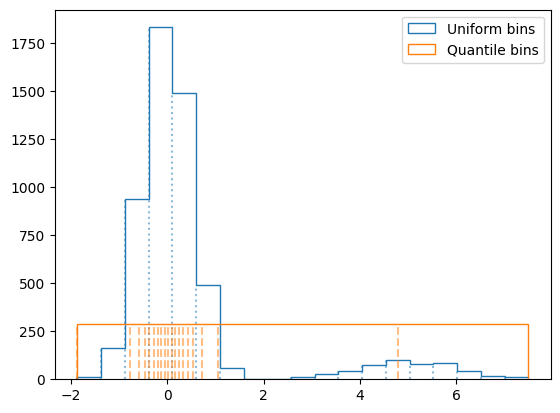

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Data
np.random.seed(0)
x = np.concatenate([np.random.normal(0, 0.5, 5000), np.random.normal(5, 1, 500)])

# Bin edges
bins_uniform = np.linspace(np.min(x), np.max(x), 20)
bins_quantile = np.quantile(x, np.linspace(0, 1, 20))

# Plot
fig, ax = plt.subplots()

# Uniform histogram
counts_uniform, edges_uniform, _ = ax.hist(x, bins=bins_uniform, histtype='step', label='Uniform bins', color='C0')
for i in range(len(edges_uniform)-1):
    ax.vlines(edges_uniform[i], 0, counts_uniform[i], color='C0', linestyle=':', alpha=0.5)

# Quantile histogram
counts_quantile, edges_quantile, _ = ax.hist(x, bins=bins_quantile, histtype='step', label='Quantile bins', color='C1')
for i in range(len(edges_quantile)-1):
    ax.vlines(edges_quantile[i], 0, counts_quantile[i], color='C1', linestyle='--', alpha=0.5)

ax.legend()
plt.show()

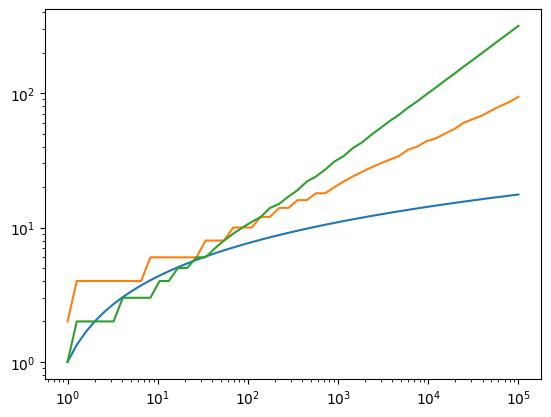

In [86]:
ns = np.geomspace(1, 100000)
plt.plot(ns, np.log2(ns)+1)
plt.plot(ns, np.maximum(1, 2*np.ceil(ns**(1/3)).astype(int)))
plt.plot(ns, np.ceil(ns**(1/2)))
plt.xscale('log')
plt.yscale('log')
plt.show()

In [89]:
import numpy as np
from numba.types import int64, float64
from numba.experimental import jitclass

@jitclass
class Propositionalization:

    v: int64[:]
    t: float64[:]
    s: int64[:]

    def __init__(self, v, t, s):
        self.v = v
        self.t = t
        self.s = s

    def support(self, p, x):
        return np.flatnonzero(self.s[p]*x[:,self.v[p]] >= self.t[p])
    
    def binarize(self, x):
        return self.s*x[:, self.v] >= self.t

def quantile_based_propositionalization(x, k=None):
    n, d = x.shape
    k = k if k is not None else 2*np.ceil(n**(1/3)).astype(int)
    quantile_targets = np.linspace(0, 1, k + 1)[1:-1]

    quantiles = np.quantile(x, quantile_targets, axis=0)  # shape (n_splitpoints, n_cols)
    v = np.repeat(np.arange(d), quantiles.shape[0])
    t = quantiles.flatten()

    # eliminate duplicate thresholds
    keep = np.empty_like(v, dtype=bool)
    keep[0] = True
    keep[1:] = (v[1:] != v[:-1]) | (t[1:] != t[:-1])
    v, t = v[keep], t[keep]

    s = np.repeat([1, -1], len(v))
    return Propositionalization(np.concatenate((v, v)), np.concatenate((t, -t)), s)

In [ ]:
def equal_width_propositionalization(x):
    n, d = x.shape

    # Compute IQR and basic parameters
    q75 = np.percentile(x, 75, axis=0)
    q25 = np.percentile(x, 25, axis=0)
    iqr = q75 - q25

    width = 2 * iqr / np.maximum(1, n**(1/3))
    l = np.nanmin(x, axis=0)
    u = np.nanmax(x, axis=0)

    v = []
    t = []

    for j in range(d):
        if width[j] == 0 or u[j] == l[j]:
            continue  # Skip degenerate columns

        n_bins = int(np.ceil((u[j] - l[j]) / width[j]))
        if n_bins <= 1:
            continue

        edges = l[j] + width[j] * np.arange(1, n_bins)

        # Now eliminate edges that don't separate points
        col_data = x[:, j]
        left_counts = np.sum(col_data <= edges[:, None], axis=1)
        right_counts = np.sum(col_data < edges[:, None], axis=1)
        nonempty = (left_counts - right_counts) > 0

        edges = edges[nonempty]

        v.extend([j] * len(edges))
        t.extend(edges)

    return np.array(v), np.array(t)

## Small sample continuous case

In [151]:
import numpy as np
RNG = np.random.default_rng(seed=0)

x_cont_small = RNG.normal(size=10)[:, np.newaxis]
np.sort(x_cont_small[:, 0])

array([-1.26542147, -0.70373524, -0.53566937, -0.13210486,  0.10490012,
        0.12573022,  0.36159505,  0.64042265,  0.94708096,  1.30400005])

In [152]:
prop = quantile_based_propositionalization(x_cont_small)
prop.t

array([-0.6197023 , -0.13210486,  0.11531517,  0.36159505,  0.79375181,
        0.6197023 ,  0.13210486, -0.11531517, -0.36159505, -0.79375181])

In [154]:
x_cont_small

array([[ 0.12573022],
       [-0.13210486],
       [ 0.64042265],
       [ 0.10490012],
       [-0.53566937],
       [ 0.36159505],
       [ 1.30400005],
       [ 0.94708096],
       [-0.70373524],
       [-1.26542147]])

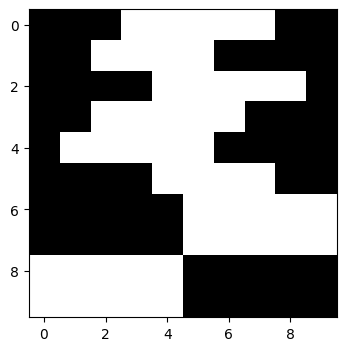

In [153]:
binary = prop.binarize(x_cont_small)
plt.figure(figsize=(12, 4))
plt.imshow(binary, cmap='Greys', interpolation='none')
plt.show()

## Continuous mid-sized

In [118]:
x_cont_mid = RNG.multivariate_normal([0, 0, 0, 0], [[1, 0.5, -0.5, -0.5],[0.5, 1, -0.5, -0.5], [-0.5, -0.5, 1, 0.5], [-0.5, -0.5, 0.5, 1]], size=500)
x_cont_mid


array([[-0.75113878,  0.85046478,  0.503436  ,  0.61247806],
       [-0.17754485,  1.42176375, -1.69356293, -0.50680273],
       [ 0.33518303, -0.10502528,  0.33385941,  0.63492653],
       ...,
       [-0.96137862,  0.29024432,  0.33622975,  0.90241694],
       [ 0.42021863,  1.10161337, -1.89939791, -0.39591618],
       [ 0.00849124, -0.00567229,  0.28037343, -0.64443634]],
      shape=(500, 4))

In [119]:
prop = quantile_based_propositionalization(x_cont_mid)
len(prop.v)

120

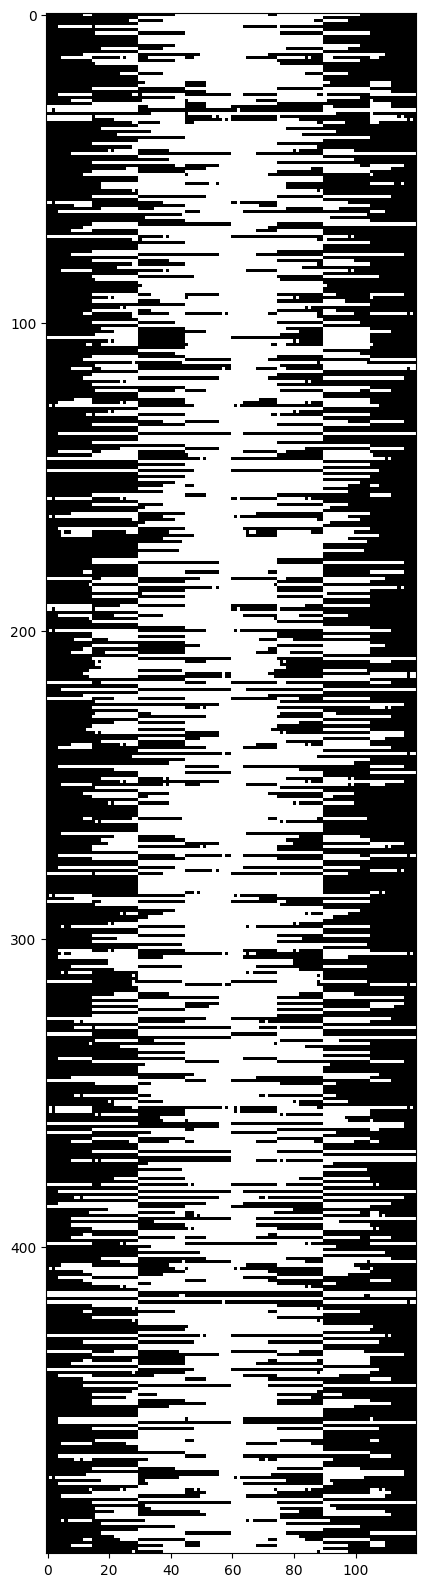

In [120]:
binary = prop.binarize(x_cont_mid)
plt.figure(figsize=(12, 20))
plt.imshow(binary, cmap='Greys', interpolation='none')
plt.show()

In [148]:
x_discr_small = RNG.binomial(1, 0.05, 10)
x_discr_small

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [150]:
prop = quantile_based_propositionalization(x_discr_small[:, np.newaxis])
prop.t

array([ 0., -0.])

In [146]:
x_discr_mid = np.random.poisson(6, 1000)[:, np.newaxis]
np.unique(x_discr_mid)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 17])

In [147]:
prop = quantile_based_propositionalization(x_discr_mid)
prop.t


array([  2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  -2.,  -3.,
        -4.,  -5.,  -6.,  -7.,  -8.,  -9., -10.])